In [ ]:
#1
import numpy as np
from sympy import *

A = np.array([[1,-2,3], [2,3,-1], [0,-2,1]]);
B = np.array([7,0,7])

invA = np.linalg.inv(A)
X = invA.dot(B)

print(X)
print(A.dot(X))


[ 6. -5. -3.]
[7. 0. 7.]


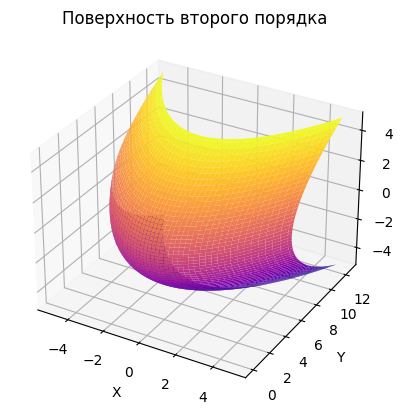

In [ ]:
#2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

x = np.linspace(-5, 5, 100)
z = np.linspace(-5, 5, 100)
x, z = np.meshgrid(x, z)
y = x**2/4 + z**2/4

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap='plasma')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Поверхность второго порядка')

plt.show()


In [ ]:
#3
from sympy import Matrix, symbols, pprint, linsolve

coef = Matrix([[-1, 2, 1, 1], [-1, 2, 1, -1], [-2, 4, 2, 4]])
cons = Matrix([2, -3, 9])

if coef.rank() == coef.row_join(cons).rank():
    reduced, pivot_columns = coef.rref()
    pprint(reduced)

    x1, x2, x3, x4 = symbols('x1 x2 x3 x4')

    solution = linsolve((coef, cons), x1, x2, x3, x4)
    pprint(solution)
    x1, x2, x3, x4 = symbols('x1 x2 x3 x4')
    assumed_solution = {x1: 2*x2+x3+1/2, x2: x2, x3: x3, x4: 5/2}

    if all(eq.subs(assumed_solution) == 0 for eq in (coef * Matrix([x1, x2, x3, x4]) - cons)):
        print("Частное решение верно.")
    else:
        print("Частное решение неверно.")
else:
    print("Система несовместна.")

⎡1  -2  -1  0⎤
⎢            ⎥
⎢0  0   0   1⎥
⎢            ⎥
⎣0  0   0   0⎦
{(2⋅x₂ + x₃ + 1/2, x₂, x₃, 5/2)}
Частное решение верно.


In [ ]:
#4
from sympy import symbols, Eq, solve

t = symbols('t')

line_x = 2 - 4 * t
line_y = t
line_z = -3 + 2 * t

x, y, z = symbols('x y z')
plane_equation = Eq(5 * x - 6 * y + 2 * z - 10, 0)

substituted_plane = plane_equation.subs({x: line_x, y: line_y, z: line_z})

solution = solve(substituted_plane, t)

if solution:
    print("Прямая и плоскость пересекаются.")
else:
    print("Прямая либо лежит в плоскости, либо параллельна ей.")

Прямая и плоскость пересекаются.


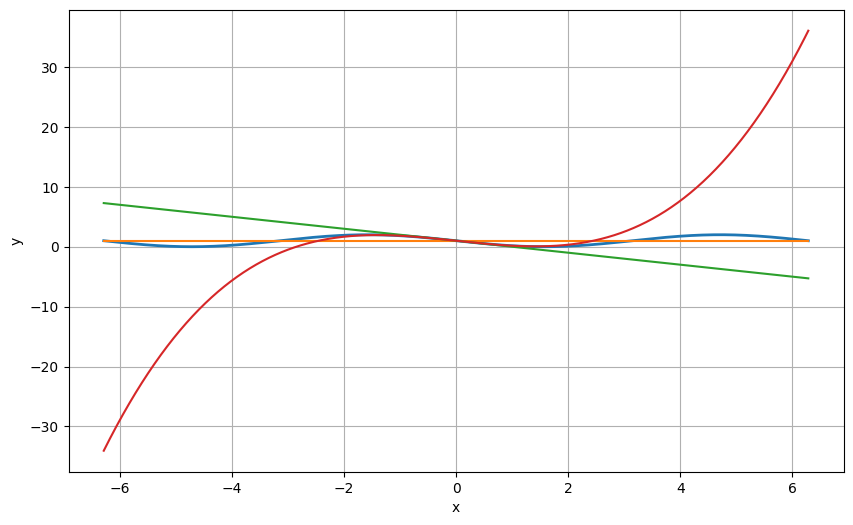

In [ ]:
#5
import matplotlib.pyplot as plt
import numpy as np
from sympy import sin, diff, lambdify

x = symbols('x')
f = 1-sin(x)
x0 = 0

n_values = [1, 3, 5]
taylor_polynomials = []

for n in n_values:
    taylor = f.series(x, x0, n).removeO()
    taylor_polynomials.append(taylor)

f_np = lambdify(x, f, modules='numpy')
taylor_polynomials_np = [lambdify(x, taylor, modules='numpy') for taylor in taylor_polynomials]

x_vals = np.linspace(-2*np.pi, 2*np.pi, 1000)

plt.figure(figsize=(10, 6))

plt.plot(x_vals, f_np(x_vals), label='sin(x)', linewidth=2)

for i, taylor_np in enumerate(taylor_polynomials_np):
    y_vals_taylor = [taylor_np(x_val) for x_val in x_vals]  # Оценка многочленов Тейлора на x_vals
    plt.plot(x_vals, y_vals_taylor, label=f'Taylor (n={n_values[i]})')

plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


## Отчет по лабораторной работе

### Задание 1: Решение системы линейных уравнений с использованием NumPy

**Цель:** Решить систему линейных алгебраических уравнений (СЛАУ) вида $AX = B$, где $A$ — матрица коэффициентов, $X$ — вектор неизвестных, и $B$ — вектор свободных членов.

**Метод:** Использована библиотека `NumPy` для выполнения матричных операций. Решение найдено путем умножения обратной матрицы $A^{-1}$ на вектор $B$ ($X = A^{-1}B$).

**Реализация:**
1.  Матрица $A = \begin{pmatrix} 1 & -2 & 3 \\ 2 & 3 & -1 \\ 0 & -2 & 1 \end{pmatrix}$ и вектор $B = \begin{pmatrix} 7 \\ 0 \\ 7 \end{pmatrix}$ определены с использованием `np.array`.
2.  Обратная матрица $A^{-1}$ вычислена с помощью `np.linalg.inv(A)`.
3.  Вектор решений $X$ получен путем матричного умножения $A^{-1}$ на $B$ с использованием метода `dot()`.
4.  Для проверки корректности решения, исходная матрица $A$ умножена на найденный вектор $X$.

**Результат:**
Полученное решение $X = \begin{pmatrix} 6 \\ -5 \\ -3 \end{pmatrix}$. Проверка $AX$ дала $AX = \begin{pmatrix} 7 \\ 0 \\ 7 \end{pmatrix}$, что соответствует вектору $B$, подтверждая правильность решения.

### Задание 2: Построение поверхности второго порядка в 3D

**Цель:** Визуализировать поверхность второго порядка в трехмерном пространстве.

**Метод:** Использована библиотека `Matplotlib` с модулем `mpl_toolkits.mplot3d` для создания 3D-графика. Построена параболоидная поверхность, заданная уравнением $y = \frac{x^2}{4} + \frac{z^2}{4}$.

**Реализация:**
1.  Диапазоны значений для $x$ и $z$ определены с помощью `np.linspace`.
2.  Создана сетка значений $x$ и $z$ с использованием `np.meshgrid`.
3.  Вычислены соответствующие значения $y$ по формуле поверхности.
4.  Создан 3D-график с помощью `fig.add_subplot(111, projection='3d')`.
5.  Поверхность построена функцией `ax.plot_surface` с цветовой картой `plasma`.
6.  Оси подписаны, и добавлен заголовок графика.

**Результат:**
Построен 3D-график параболоидной поверхности, наглядно демонстрирующий ее форму в трехмерном пространстве.

### Задание 3: Решение системы линейных уравнений с использованием SymPy

**Цель:** Решить неоднородную систему линейных алгебраических уравнений и проверить, является ли заданное частное решение верным.

**Метод:** Использована символьная библиотека `SymPy` для работы с матрицами и решения систем уравнений. Применялся метод рангов для проверки совместности системы и функция `linsolve` для нахождения общего решения.

**Реализация:**
1.  Матрица коэффициентов `coef` и вектор свободных членов `cons` определены как объекты `sympy.Matrix`.
2.  Проверка совместности системы выполнена сравнением рангов основной и расширенной матриц (`coef.rank() == coef.row_join(cons).rank()`).
3.  Если система совместна, приведена к ступенчатому виду (`coef.rref()`) и выведено общее решение с помощью `linsolve((coef, cons), x1, x2, x3, x4)`.
4.  Задано предполагаемое частное решение, и проверено его соответствие системе путем подстановки в исходные уравнения.

**Результат:**
Система оказалась совместной. Приведенный ступенчатый вид матрицы и общее решение `{(2⋅x₂ + x₃ + 1/2, x₂, x₃, 5/2)}` были выведены. Проверка показала, что заданное частное решение является верным.

### Задание 4: Определение взаимного расположения прямой и плоскости

**Цель:** Определить, пересекается ли заданная прямая с заданной плоскостью.

**Метод:** Использована символьная библиотека `SymPy` для подстановки параметрических уравнений прямой в уравнение плоскости и решения полученного уравнения относительно параметра `t`.

**Реализация:**
1.  Символы `t`, `x`, `y`, `z` определены с помощью `symbols`.
2.  Параметрические уравнения прямой ($x = 2 - 4t$, $y = t$, $z = -3 + 2t$) заданы символьными выражениями.
3.  Уравнение плоскости ($5x - 6y + 2z - 10 = 0$) задано как объект `sympy.Eq`.
4.  Параметрические уравнения прямой подставлены в уравнение плоскости с использованием метода `subs()`.
5.  Полученное символьное уравнение решено относительно `t` с помощью `solve()`.
6.  На основе наличия решения для `t` сделан вывод о взаимном расположении прямой и плоскости.

**Результат:**
В результате вычислений было установлено, что прямая и плоскость пересекаются, так как для параметра `t` было найдено конкретное числовое значение.

### Задание 5: Разложение функции в ряд Тейлора и его визуализация

**Цель:** Разложить функцию $f(x) = 1 - \sin(x)$ в ряд Тейлора вокруг точки $x_0 = 0$ для различных порядков $n$ и визуализировать эти разложения.

**Метод:** Использована библиотека `SymPy` для символьного разложения функции в ряд Тейлора (`.series().removeO()`) и `Matplotlib` для построения графиков исходной функции и ее приближений.

**Реализация:**
1.  Символ `x` и функция `f = 1 - sin(x)` определены в `SymPy`.
2.  Для разных порядков $n$ (1, 3, 5) вычислены полиномы Тейлора.
3.  Символьные выражения функции и полиномов Тейлора преобразованы в численные функции (`lambdify`) для их оценки на массиве значений `x_vals`.
4.  Построены графики исходной функции и ее приближений Тейлора на интервале от $-2\pi$ до $2\pi$.
5.  Добавлены подписи осей, заголовок и легенда.

**Результат:**
На графике показана исходная функция $1 - \sin(x)$ и ее приближения полиномами Тейлора первого, третьего и пятого порядков. Видно, что с увеличением порядка $n$ полином Тейлора лучше аппроксимирует исходную функцию вокруг точки $x_0 = 0$.